In [ ]:
# --- LIBRARIES ---

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
from collections import deque

# ------------------------------------------------------------------------------

In [ ]:
# --- ENVIRONMENT AND UTILITIES ---

# --- Environment of Cluster Routing
class TSPEnvFixedStartGoal:

    def __init__(self, coords, start_cluster, goal_cluster):

        self.coords = coords
        self.n = len(coords)
        self.start_cluster = start_cluster
        self.goal_cluster = goal_cluster
        assert start_cluster != goal_cluster,

        # Precompute all pairwise distances: shape (n, n)
        self.dist = np.linalg.norm(coords[:, None] - coords[None, :], axis=2)
        self.reset()

    def reset(self):

        self.visited = np.zeros(self.n, dtype=np.bool_)
        self.visited[self.start_cluster] = True  # Already at start
        self.position = self.start_cluster
        return self._get_state()

    def _get_state(self):

        pos_vec = np.zeros(self.n, dtype=np.float32)
        mask_vec = self.visited.astype(np.float32)
        pos_vec[self.position] = 1.0
        return np.concatenate([pos_vec, mask_vec])

    def step(self, action):
        """action: next cluster index."""
        if self.visited.all():  # All visited, final decision
            if action == self.goal_cluster:
                reward = 1000.0  # BIG reward for correct goal
            else:
                reward = -1000.0  # BIG penalty for wrong end
            done = True
            return self._get_state(), reward, done, {}

        # Normal step: visit next unvisited cluster
        assert not self.visited[action], f"Action {action} already visited!"
        d = self.dist[self.position, action]
        reward = -d  # Minimize distance
        self.position = action
        self.visited[action] = True
        done = self.visited.all()
        return self._get_state(), reward, done, {}

# --- First Greedy Nearest Neighbor Path Finder
class SimplifiedOrchardPathfinder:

    def __init__(self, real_width_m, real_height_m, fruit_data, start_pos_m=(0.0, 0.0)):

        self.real_width_m = real_width_m
        self.real_height_m = real_height_m
        self.original_fruit_data = fruit_data # list of (x_m, y_m, initial_weight)
        self.start_pos_m = np.array(start_pos_m, dtype=np.float32)

        self.current_agent_pos = self.start_pos_m.copy()
        self.unvisited_fruits = {} # {(x,y): weight}
        self.visited_fruits_in_order = [] # Stores (x,y,weight) of visited fruits
        self.total_distance = 0.0
        self.total_harvested_weight = 0

        self.reset()

    def reset(self):

        self.current_agent_pos = self.start_pos_m.copy()
        self.unvisited_fruits = {}
        for fx, fy, fw in self.original_fruit_data:
            self.unvisited_fruits[(float(fx), float(fy))] = fw
        self.visited_fruits_in_order = []
        self.total_distance = 0.0
        self.total_harvested_weight = 0

    def find_path_greedy(self, strategy="weight_distance_ratio"):

        self.reset()
        self.visited_fruits_in_order.append((self.start_pos_m[0], self.start_pos_m[1], 0))

        while self.unvisited_fruits:

            best_next_fruit_pos = None
            best_score = -np.inf

            for fruit_pos, weight in self.unvisited_fruits.items():

                distance = np.linalg.norm(self.current_agent_pos - np.array(fruit_pos))

                if distance == 0:
                    score = np.inf # Highest possible score
                elif strategy == "nearest":
                    score = -distance # Minimize distance
                elif strategy == "weight_distance_ratio":
                    # Avoid division by zero if distance is very small or zero
                    score = weight / (distance + 1e-6)
                else:
                    raise ValueError("Unknown strategy")

                if score > best_score:
                    best_score = score
                    best_next_fruit_pos = fruit_pos

            if best_next_fruit_pos is None:
                break

            # Move to the best next fruit
            dist_to_move = np.linalg.norm(self.current_agent_pos - np.array(best_next_fruit_pos))
            self.total_distance += dist_to_move
            self.current_agent_pos = np.array(best_next_fruit_pos)

            # Harvest the fruit
            harvested_weight = self.unvisited_fruits[best_next_fruit_pos]
            self.total_harvested_weight += harvested_weight
            self.visited_fruits_in_order.append((best_next_fruit_pos[0], best_next_fruit_pos[1], harvested_weight))
            del self.unvisited_fruits[best_next_fruit_pos]

        return self.visited_fruits_in_order, self.total_distance, self.total_harvested_weight

# --- DDQN Network
class DDQN(nn.Module):

    def __init__(self, state_dim, n_actions):

        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions),
        )

    def forward(self, x):
        return self.net(x)

# --- Replay Buffer
class ReplayBuffer:

    def __init__(self, capacity=100000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = map(np.array, zip(*batch))
        return state, action, reward, next_state, done.astype(np.float32)

    def __len__(self):
        return len(self.buffer)

# --- DDQN Agent
class DDQNAgent:

    def __init__(self, state_dim, n_actions, lr=1e-4, gamma=0.99, eps_decay_steps=50000):

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.n_actions = n_actions
        self.gamma = gamma
        self.eps_decay_steps = eps_decay_steps
        self.eps = 1.0

        # Networks
        self.q_net = DDQN(state_dim, n_actions).to(self.device)
        self.target_net = DDQN(state_dim, n_actions).to(self.device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)

        self.replay_buffer = ReplayBuffer(100000)

    def act(self, state, valid_actions):

        if np.random.rand() < self.eps:
            return random.choice(valid_actions)

        state_t = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            q_vals = self.q_net(state_t).cpu().numpy().flatten()
        q_vals_valid = q_vals[valid_actions]
        best_idx = np.argmax(q_vals_valid)
        return valid_actions[best_idx]

    def update(self, batch_size):

        if len(self.replay_buffer) < batch_size:
            return

        s, a, r, s_next, done = self.replay_buffer.sample(batch_size)
        s = torch.FloatTensor(s).to(self.device)
        a = torch.LongTensor(a).to(self.device)
        r = torch.FloatTensor(r).to(self.device)
        s_next = torch.FloatTensor(s_next).to(self.device)
        done = torch.FloatTensor(done).to(self.device)

        # Current Q-values
        q_vals = self.q_net(s).gather(1, a.unsqueeze(1)).squeeze(1)

        # Target Q-values (DDQN)
        with torch.no_grad():
            q_next = self.q_net(s_next)
            q_target_next = self.target_net(s_next)
            best_a_next = q_next.argmax(1)
            q_target = q_target_next.gather(1, best_a_next.unsqueeze(1)).squeeze(1)
            q_target = r + self.gamma * q_target * (1 - done)

        # Loss
        loss = F.mse_loss(q_vals, q_target)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Epsilon decay
        self.eps = max(0.01, 1.0 - len(self.replay_buffer) / self.eps_decay_steps)

        # Target network soft update
        tau = 0.005
        for target_param, online_param in zip(self.target_net.parameters(), self.q_net.parameters()):
            target_param.data.copy_(tau * online_param.data + (1.0 - tau) * target_param.data)

# --- Route Distance (with cluster order)
def total_route_distance(coords, route):

    d = 0.0
    for i in range(len(route) - 1):
        d += np.linalg.norm(coords[route[i + 1]] - coords[route[i]])
    return d

# --- Run episode
def collect_rollout(env, agent):

    state = env.reset()
    route = [env.start_cluster]
    total_reward = 0.0

    while True:

        valid_actions = np.where(~env.visited)[0].tolist()
        if not valid_actions:  # All visited, final goal choice
            valid_actions = list(range(env.n))

        action = agent.act(state, valid_actions)
        next_state, reward, done, _ = env.step(action)

        route.append(action)
        total_reward += reward
        agent.replay_buffer.push(state, action, reward, next_state, done)
        state = next_state

        if done:
            break

    return total_reward, route

# --- Divide Plane in Sections
def split_points_into_grid(points, c, r):

    points = np.asarray(points)
    x = points[:, 0]
    y = points[:, 1]

    # Bounds
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()

    # Avoid division by zero
    x_range = x_max - x_min if x_max > x_min else 1
    y_range = y_max - y_min if y_max > y_min else 1

    # Compute indices
    col_idx = ((x - x_min) / x_range * c).astype(int)
    row_idx = ((y - y_min) / y_range * r).astype(int)

    # Fix edge case where value == max
    col_idx = np.clip(col_idx, 0, c - 1)
    row_idx = np.clip(row_idx, 0, r - 1)

    # Create grid (list of lists)
    grid = [[[] for _ in range(c)] for _ in range(r)]

    # Assign points
    for i in range(len(points)):
        grid[row_idx[i]][col_idx[i]].append(points[i])

    # Convert lists to numpy arrays
    for i in range(r):
        for j in range(c):
            grid[i][j] = np.array(grid[i][j])

    return grid

# --- 2Opt Refinement Operation
def two_opt_route(route, coords, max_iters=1000):

    route = route.copy()
    n = len(route)
    best_dist = total_route_distance(coords, route)
    improved = True

    iter_count = 0
    while improved and iter_count < max_iters:
        improved = False
        for i in range(1, n - 2):
            for j in range(i + 1, n):
                if j == n - 1:
                    break

                # New edges: i→j+1 and j→i+1 (reverse i+1 to j)
                old_dist = (np.linalg.norm(coords[route[i]] - coords[route[i+1]]) +
                           np.linalg.norm(coords[route[j]] - coords[route[j+1]]))

                new_dist = (np.linalg.norm(coords[route[i]] - coords[route[j+1]]) +
                           np.linalg.norm(coords[route[j]] - coords[route[i+1]]))

                if new_dist < old_dist:
                    # Reverse segment i+1 to j
                    route[i+1:j+1] = route[i+1:j+1][::-1]
                    improved = True

        iter_count += 1

    new_dist = total_route_distance(coords, route)
    return route, new_dist, (best_dist - new_dist) / best_dist * 100

# ------------------------------------------------------------------------------

In [ ]:
# --- MDDEL PARAMETERS SETUP (Repeat for each section) ---

# Environment dimensions
REAL_WIDTH = 22.42
REAL_HEIGHT = 13.06

# Collect data
cluster_coor = np.load('cluster_data.npy')

# Select a section from the divided plane
grid = split_points_into_grid(cluster_coor, c=5, r=2)
fruit_clusters_m = grid[0][0][:, 0:2]

# Select start and goal points
max_value = max(fruit_clusters_m[:, 1])
max_index = np.argmax(fruit_clusters_m[:, 1])
min_value = min(fruit_clusters_m[:, 1])
min_index = np.argmin(fruit_clusters_m[:, 1])
start_cluster = min_index
goal_cluster = max_index

# Get number of nodes
n_clusters = fruit_clusters_m[:, 1].shape[0]

# Show process initialization
print(f"Vertical farthest node: {max_index}. Value: {max_value}")
print(f"Vertical closest node: {min_index}. Value: {min_value}")
print(f"Total nodes in this section: {n_clusters}")
print(f"Clusters: {n_clusters} | Start: {start_cluster} | Goal: {goal_cluster}")

coords = fruit_clusters_m
START_POS = (fruit_clusters_m[min_index][0], fruit_clusters_m[min_index][1])

# Environment call
env = TSPEnvFixedStartGoal(coords, start_cluster, goal_cluster)

# Agent
state_dim = 2 * n_clusters
agent = DDQNAgent(state_dim, n_clusters, lr=1e-5, gamma=0.99)

# Training
n_episodes = 5000
batch_size = 128
record_reward = []
record_distance = []
best_distance = float('inf')
best_route = None
last_distance = float('inf')
last_route = None

# Initiate DDQN training process
print("\nTraining DDQN agent...")
for e in range(1, n_episodes + 1):
    total_reward, route = collect_rollout(env, agent)
    distance = total_route_distance(coords, route)

    record_reward.append(total_reward)
    record_distance.append(distance)

    # Track best route
    if distance < best_distance:
        best_distance = distance
        best_route = route.copy()

    # Train
    for _ in range(4):
        agent.update(batch_size)

    if e % 200 == 0:
        avg_dist = np.mean(record_distance[-100:])
        print(f"Ep {e:4d} | Dist: {distance:6.1f} | "
              f"Avg100: {avg_dist:6.1f} | eps: {agent.eps:.3f}")

    if e == n_episodes:
        last_distance = distance
        last_route = route.copy()

# Initialice Nearest Neighbor Greedy model
pathfinder = SimplifiedOrchardPathfinder(REAL_WIDTH, REAL_HEIGHT, [tuple(row) for row in grid[0][0]], START_POS)
path_nearest, dist_nearest, weight_nearest = pathfinder.find_path_greedy(strategy="nearest")

# Refine DDQN route by 2Opt
opt_route, opt_dist, pct_improvement = two_opt_route(best_route, coords)

print("\n--- Finding path using 'nearest' strategy ---")
print(f"Best route length: {len(path_nearest)-1} nodes.")
print(f"Nearest Best distance found: {dist_nearest:.2f} meters")

print("\n--- Finding path using DDQN strategy ---")
print(f"Best route length: {len(best_route)} nodes")
print(f"DDQN Best distance found: {best_distance:.2f}")

print("\n--- Finding path using 2_OPT-DDQN strategy ---")
print(f"Best route length: {opt_dist:.2f}")
print(f"Improvement: {pct_improvement:.1f}% shorter")

# ------------------------------------------------------------------------------

Vertical farthest node: 31. Value: 6.6
Vertical closest node: 1. Value: 1.34
Total nodes in this section: 34
Clusters: 34 | Start: 1 | Goal: 31

Training DDQN agent...
Ep  200 | Dist:   85.9 | Avg100:   83.1 | eps: 0.868
Ep  400 | Dist:   80.7 | Avg100:   83.8 | eps: 0.736
Ep  600 | Dist:   71.8 | Avg100:   80.8 | eps: 0.604
Ep  800 | Dist:   83.8 | Avg100:   78.1 | eps: 0.472
Ep 1000 | Dist:   78.5 | Avg100:   71.6 | eps: 0.340
Ep 1200 | Dist:   70.8 | Avg100:   62.4 | eps: 0.208
Ep 1400 | Dist:   49.2 | Avg100:   50.6 | eps: 0.076
Ep 1600 | Dist:   38.2 | Avg100:   39.8 | eps: 0.010
Ep 1800 | Dist:   39.1 | Avg100:   39.0 | eps: 0.010
Ep 2000 | Dist:   37.4 | Avg100:   38.5 | eps: 0.010
Ep 2200 | Dist:   33.0 | Avg100:   36.2 | eps: 0.010
Ep 2400 | Dist:   33.3 | Avg100:   35.4 | eps: 0.010
Ep 2600 | Dist:   31.8 | Avg100:   32.2 | eps: 0.010
Ep 2800 | Dist:   31.8 | Avg100:   31.7 | eps: 0.010
Ep 3000 | Dist:   28.7 | Avg100:   29.4 | eps: 0.010
Ep 3200 | Dist:   29.5 | Avg100:   29

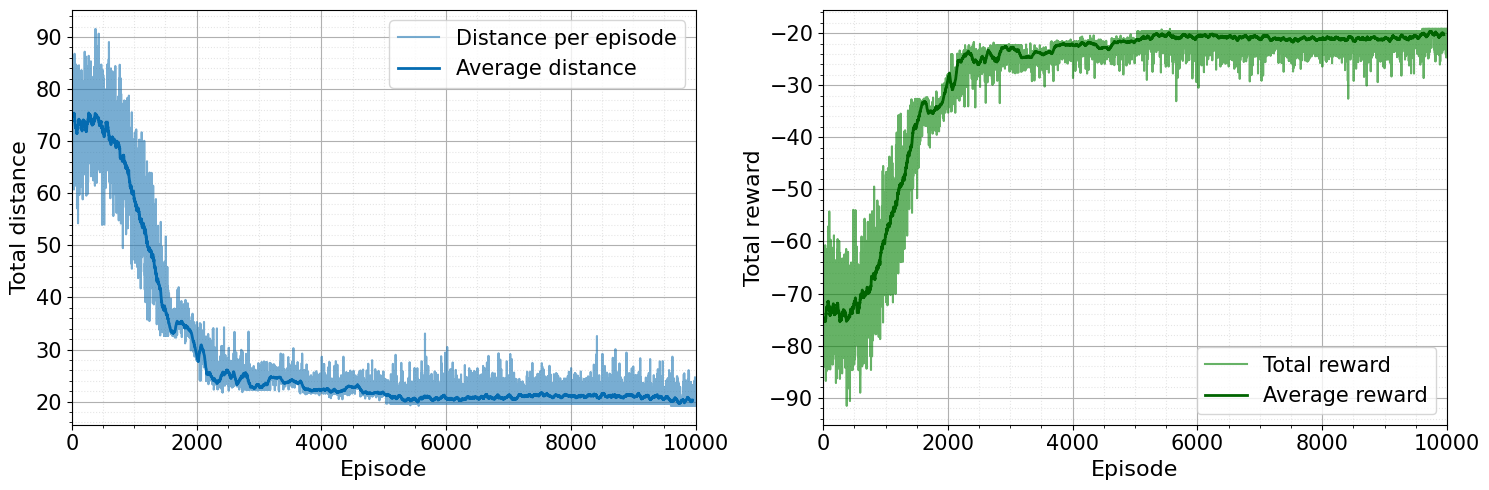

In [ ]:
# --- PLOT TRAINING PROCESS ---

# Initialize figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot distance evolution during training
ax1.plot(record_distance, alpha=0.6, label="Distance per episode")
ax1.plot(np.convolve(record_distance, np.ones(50)/50, mode="valid"),
          color="#046bb1", linewidth=2, label="Average distance")
ax1.set_xlabel("Episode", fontsize=16)
ax1.set_ylabel("Total distance", fontsize=16)
ax1.legend()
ax1.grid(True)
ax1.minorticks_on()
ax1.grid(visible=True, which='minor', color='gray', linestyle=':', alpha=0.2)
ax1.tick_params(axis='both', labelsize=15)
ax1.set_xlim(0, n_episodes)
ax1.legend(fontsize=15)

# Plot reward evolution during training
ax2.plot(record_reward, alpha=0.6, color="green", label="Total reward")
ax2.plot(np.convolve(record_reward, np.ones(50)/50, mode="valid"),
          color="darkgreen", linewidth=2, label="Average reward")
ax2.set_xlabel("Episode", fontsize=16)
ax2.set_ylabel("Total reward", fontsize=16)
ax2.legend()
ax2.grid(True)
ax2.minorticks_on()
ax2.grid(visible=True, which='minor', color='gray', linestyle=':', alpha=0.2)
ax2.tick_params(axis='both', labelsize=15)
ax2.set_xlim(0, n_episodes)
ax2.legend(fontsize=15)
# plt.savefig("figure.svg", bbox_inches='tight') # For saving
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------

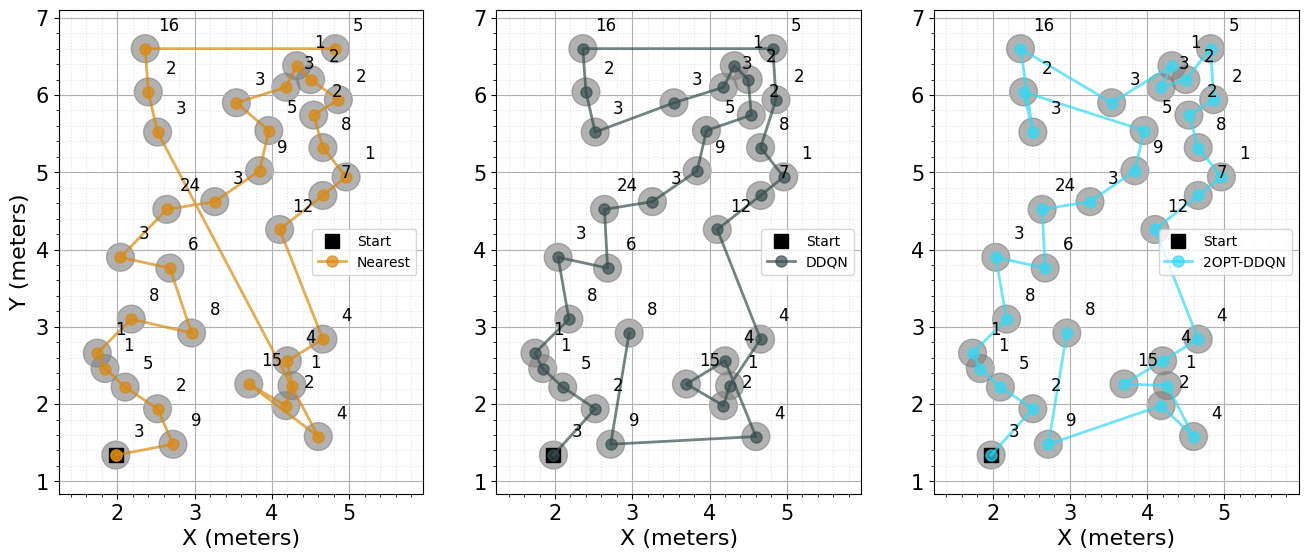

In [ ]:
# --- ROUTE RESULT PER SECTION ---

# Limits for this section
real_width_m = [min(fruit_clusters_m[:, 0]), max(fruit_clusters_m[:, 0])]
real_height_m = [min(fruit_clusters_m[:, 1]), max(fruit_clusters_m[:, 1])]
fruit_clusters_ma = grid[0][0][:, 0:3]

# Initialize figure
fig, (axa, axb, axc) = plt.subplots(1, 3, figsize=(16, 11))

# --- Greedy Nearest Neighbor Plot

axa.set_xlim(real_width_m[0] -0.5 , real_width_m[1] + 1)
axa.set_ylim(real_height_m[0] -0.5, real_height_m[1] + 0.5)
axa.set_aspect('equal', adjustable='box')
axa.set_xlabel("X (meters)", fontsize=16)
axa.set_ylabel("Y (meters)", fontsize=16)

# Draw original fruit clusters
all_fruit_coords = [(f[0], f[1], f[2]) for f in fruit_clusters_ma]

for i, (fx, fy, fw) in enumerate(all_fruit_coords):
    circle = plt.Circle((fx, fy), 0.18, color='gray', alpha=0.6)
    axa.add_patch(circle)
    axa.text(fx+0.3, fy+0.3, int(fw+1), color='black', ha='center', va='center', fontsize=12)

# Draw start position
axa.plot(fruit_clusters_m[min_index][0], fruit_clusters_m[min_index][1], 'ks', markersize=10, label='Start') # Black Square for Start

# Draw the path
path_x = [p[0] for p in path_nearest]
path_y = [p[1] for p in path_nearest]
axa.plot(path_x, path_y, '-o', alpha=0.7, markersize=8, linewidth=2, label='Nearest', color='#d98810')
axa.legend()
axa.grid(True)
axa.minorticks_on()
axa.grid(visible=True, which='minor', color='gray', linestyle=':', alpha=0.2)
axa.tick_params(axis='both', labelsize=15)

# --- DDQN Plot

axb.set_xlim(real_width_m[0] - 0.5, real_width_m[1] + 1)
axb.set_ylim(real_height_m[0] - 0.5, real_height_m[1] + 0.5)
axb.set_aspect('equal', adjustable='box')
axb.set_xlabel("X (meters)", fontsize=16)

# Draw original fruit clusters
all_fruit_coords = [(f[0], f[1], f[2]) for f in fruit_clusters_ma]

for i, (fx, fy, fw) in enumerate(all_fruit_coords):
    circle = plt.Circle((fx, fy), 0.18, color='gray', alpha=0.6)
    axb.add_patch(circle)
    axb.text(fx+0.3, fy+0.3, int(fw+1), color='black', ha='center', va='center', fontsize=12)

# Draw start position
axb.plot(fruit_clusters_m[min_index][0], fruit_clusters_m[min_index][1], 'ks', markersize=10, label='Start') # Black Square for Start

# Draw the path
route_coords = coords[best_route]
path_x = route_coords[:, 0]
path_y = route_coords[:, 1]
axb.plot(path_x, path_y, '-o', alpha=0.7, markersize=8, linewidth=2, label='DDQN', color='#384e4f')
axb.legend()
axb.grid(True)
axb.minorticks_on()
axb.grid(visible=True, which='minor', color='gray', linestyle=':', alpha=0.2)
axb.tick_params(axis='both', labelsize=15)

# --- 2Opt-DDQN Plot

axc.set_xlim(real_width_m[0] -0.5, real_width_m[1] + 1)
axc.set_ylim(real_height_m[0] -0.5, real_height_m[1] + 0.5)
axc.set_aspect('equal', adjustable='box')
axc.set_xlabel("X (meters)", fontsize=16)

# Draw original fruit clusters
all_fruit_coords = [(f[0], f[1], f[2]) for f in fruit_clusters_ma]

for i, (fx, fy, fw) in enumerate(all_fruit_coords):
    circle = plt.Circle((fx, fy), 0.18, color='gray', alpha=0.6)
    axc.add_patch(circle)
    axc.text(fx+0.3, fy+0.3, int(fw+1), color='black', ha='center', va='center', fontsize=12)

# Draw start position
axc.plot(fruit_clusters_m[min_index][0], fruit_clusters_m[min_index][1], 'ks', markersize=10, label='Start') # Black Square for Start

# Draw the path
route_coords = coords[opt_route]
path_x = route_coords[:, 0]
path_y = route_coords[:, 1]
axc.plot(path_x, path_y, '-o', alpha=0.7, markersize=8, linewidth=2, label='2OPT-DDQN', color='#34d8f4')
axc.legend()
axc.grid(True)
axc.minorticks_on()
axc.grid(visible=True, which='minor', color='gray', linestyle=':', alpha=0.2)
axc.tick_params(axis='both', labelsize=15)
#plt.savefig("route_section.svg", bbox_inches='tight') # For saving
plt.grid(True)
plt.show()

# ------------------------------------------------------------------------------

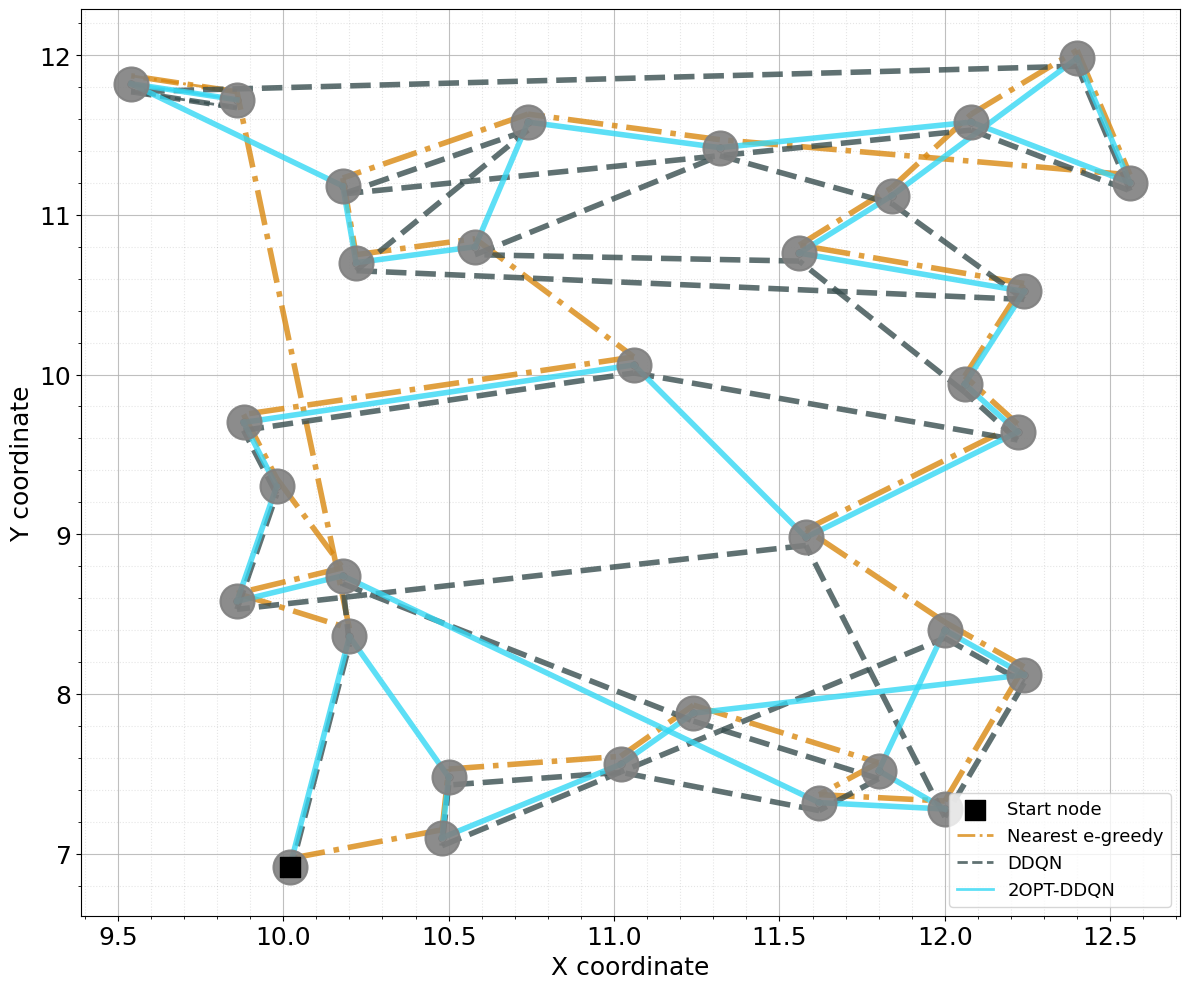

In [ ]:
# --- COMBINED PLOT ---

# Initialize figure
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# All clusters
ax.scatter(coords[:, 0], coords[:, 1], s=30, c="lightblue",
            alpha=0.7, edgecolors="black", linewidth=0.5)

# Start point
ax.scatter(coords[start_cluster, 0], coords[start_cluster, 1],
            s=200, c="black", marker="s", label=f"Start node", zorder=5)

# Best route path
path_x = np.array([p[0] for p in path_nearest])
path_y = np.array([p[1] for p in path_nearest])

# Concatenate vertically
v1_v = path_x.reshape(-1, 1)
v2_v = path_y.reshape(-1, 1)
path_route = np.hstack((v1_v, v2_v))

# -- GNN path
for i in range(len(path_route) - 1):
    x1a, y1a = path_route[i]
    x2a, y2a = path_route[i + 1]
    ax.plot([x1a, x2a], [y1a+0.05, y2a+0.05], "-.", linewidth=4, alpha=0.8, color='#d98810')
ax.plot([x1a, x2a], [y1a+0.05, y2a+0.05], "-.", linewidth=2, alpha=0.8, label='Nearest e-greedy', color='#d98810')

# -- DDQN path
for i in range(len(best_route) - 1):
    x1b, y1b = coords[best_route[i]]
    x2b, y2b = coords[best_route[i + 1]]
    ax.plot([x1b, x2b], [y1b-0.05, y2b-0.05], "--", linewidth=4, alpha=0.8, color='#384e4f')
ax.plot([x1b, x2b], [y1b-0.05, y2b-0.05], "--", linewidth=2, alpha=0.8, label='DDQN', color='#384e4f')

# -- 2Opt-DDQN path
for i in range(len(opt_route) - 1):
    x1c, y1c = coords[opt_route[i]]
    x2c, y2c = coords[opt_route[i + 1]]
    ax.plot([x1c, x2c], [y1c, y2c], "-", linewidth=4, alpha=0.8, color='#34d8f4')
ax.plot([x1c, x2c], [y1c, y2c], "-", linewidth=2, alpha=0.8, label='2OPT-DDQN', color='#34d8f4')

# Route nodes
route_coords = coords[best_route]
ax.scatter(route_coords[:, 0], route_coords[:, 1], s=600, c="gray", linewidth=1.5, zorder=4, alpha=0.9)

ax.set_xlabel("X coordinate", fontsize=18)
ax.set_ylabel("Y coordinate", fontsize=18)
ax.legend(fontsize=13)
ax.grid(True, alpha=0.8)
ax.minorticks_on()
ax.grid(visible=True, which='minor', color='gray', linestyle=':', alpha=0.2)
ax.tick_params(axis='both', labelsize=18)
plt.tight_layout()
#plt.savefig("figure.svg", bbox_inches='tight') # For saving
plt.show()

# ------------------------------------------------------------------------------

In [ ]:
# --- STORAGE SECTION DATA

# Save data to npz file
data_to_save = {"Nearest_coordinates": path_route, "Nearest_dist": dist_nearest,
                "DDPG_coordinates": coords[best_route], "DDPG_dist": best_distance,
                "2OPT-DDPG_coordinates": coords[opt_route], "2OPT-DDPG_dist": opt_dist,
                "reward": record_reward,
                "distance":record_distance}
np.savez('route6.npz', **data_to_save)

# ------------------------------------------------------------------------------